In [144]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [145]:
def f(x):
    return x**8 - 1
def df(x):
    return 8*x**7

In [146]:
# Define helper functions

def newton_raphson(p,Tol,N):
    p1 = p
    for i in range(N):
        p = p1
        p1 -= f(p1)/df(p1)
        if abs(p1-p) < Tol:
            # print("Root is:",p1,"\nIterates:",i)
            return p1
    # print("Maximum Iterates Reached!\nRoot is:",p1)
    return p1

PI = np.pi
def z(k):
    return np.cos(2*PI*k/8) + np.sin(2*PI*k/8) * 1j

def root_color(zn):
    d = abs(z(0) - zn)
    idx = 0
    for i in range(1,8,1):
        if(abs(z(i)-zn) < d):
            d = abs(z(i) - zn)
            idx = i
    return idx
        


In [147]:
n = 1000
plot_arr = np.zeros((n,n),dtype=int)

In [148]:
Tol = 1e-9
N = 1000

for i in range(n):
    for j in range(n):
        real_part = (j - (n - 1) / 2) / (n / 4)
        imag_part = (i - (n - 1) / 2) / (n / 4)
        
        x = newton_raphson(complex(real_part, imag_part), Tol, N)
        plot_arr[i][j] = root_color(x)

In [149]:
plot_arr

array([[5, 5, 5, ..., 7, 7, 7],
       [5, 5, 5, ..., 7, 7, 7],
       [5, 5, 5, ..., 7, 7, 7],
       ...,
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1]])

In [150]:
color = np.array([
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', 
    '#f58231', '#911eb4', '#42d4f4', '#f032e6'
])

# color = np.array([
#     '#001233', '#0353a4', '#00b4d8', '#90e0ef', 
#     '#7209b7', '#f72585', '#b5179e', '#4cc9f0'
# ])

# color = np.array([
#     '#2A363B', '#E84A5F', '#FF847C', '#FECEAB', 
#     '#99B898', '#355C7D', '#6C5B7B', '#C06C84'
# ])
color

array(['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4',
       '#42d4f4', '#f032e6'], dtype='<U7')

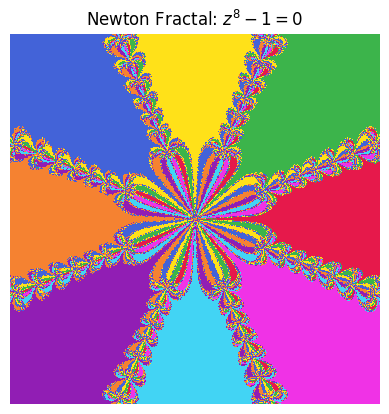

In [151]:
# 1. Create a colormap using your exact color array
custom_cmap = ListedColormap(color)

# 2. Plot the matrix
# 'origin=lower' ensures the y-axis points up like a standard graph
plt.imshow(plot_arr, cmap=custom_cmap, origin='lower')

# 3. Add titles and remove tick marks for a clean image
plt.title("Newton Fractal: $z^8 - 1 = 0$")
plt.axis('off') 
plt.show()